# Modelo de Scoring Crediticio — Regresión Logística
**Enfoque:** Credit Risk Modeling con estándares Basilea / IFRS 9  
**Métricas clave:** KS, Gini, AUC, PSI, WoE/IV, Matriz de Confusión, Scorecard  

---
## Contexto del Negocio
El objetivo es estimar la **Probabilidad de Default (PD)** a 12 meses para una cartera de crédito de consumo.  
Un cliente se considera en **Default** si presenta 90+ días de mora (definición Basilea).  

**Variable objetivo:** `DEFAULT` (1 = mal pagador, 0 = buen pagador)  
**Tasa de mora simulada:** ~15% (típica de consumo en LATAM)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Simulación de Datos
Generamos una cartera con características realistas de crédito de consumo.  
Las relaciones entre variables y default están calibradas con lógica crediticia real.

In [2]:
N = 10_000

# ---- Variables sociodemográficas ----
edad           = np.random.randint(20, 70, N)
ingreso_mensual = np.random.lognormal(mean=np.log(1_500_000), sigma=0.6, size=N).clip(300_000, 15_000_000)

# ---- Variables de comportamiento crediticio ----
meses_en_cartera    = np.random.randint(1, 84, N)                      # antigüedad del cliente
num_productos       = np.random.poisson(lam=2.5, size=N).clip(1, 8)    # productos activos
deuda_total         = np.random.lognormal(mean=np.log(2_000_000), sigma=0.8, size=N).clip(100_000, 50_000_000)
max_mora_historica  = np.random.choice([0, 30, 60, 90, 120], N, p=[0.55, 0.20, 0.12, 0.08, 0.05])
num_consultas_buro  = np.random.poisson(lam=3, size=N).clip(0, 15)     # consultas en buró últimos 6m

# ---- Ratio Deuda/Ingreso (Debt-to-Income) ----
dti = (deuda_total / (ingreso_mensual * 12)).clip(0, 5)

# ---- Score de buró externo (simulado como CIFIN/DataCrédito) ----
score_buro = (
    850
    - (max_mora_historica * 2.5)
    - (num_consultas_buro * 8)
    - (dti * 60)
    + (meses_en_cartera * 0.8)
    + np.random.normal(0, 40, N)
).clip(300, 850)

# ---- Construcción del logit para PD realista ----
logit = (
    -4.5
    + (max_mora_historica * 0.025)    # mora histórica: predictor fuerte
    + (dti * 1.8)                      # endeudamiento relativo
    + (num_consultas_buro * 0.15)      # búsqueda desesperada de crédito
    - (score_buro * 0.008)             # mejor score = menor riesgo
    - (ingreso_mensual / 3_000_000)    # ingreso protege
    - (np.log1p(meses_en_cartera) * 0.2)  # antigüedad reduce riesgo
    + np.random.normal(0, 0.3, N)      # ruido idiosincrático
)

pd_real = 1 / (1 + np.exp(-logit))
default  = np.random.binomial(1, pd_real)

df = pd.DataFrame({
    'edad': edad,
    'ingreso_mensual': ingreso_mensual,
    'meses_en_cartera': meses_en_cartera,
    'num_productos': num_productos,
    'deuda_total': deuda_total,
    'max_mora_historica': max_mora_historica,
    'num_consultas_buro': num_consultas_buro,
    'dti': dti,
    'score_buro': score_buro,
    'DEFAULT': default
})

print(f'Dataset: {df.shape[0]:,} registros  |  Tasa de mora: {df.DEFAULT.mean():.2%}')
df.head()

Dataset: 10,000 registros  |  Tasa de mora: 0.06%


,edad,ingreso_mensual,meses_en_cartera,num_productos,deuda_total,max_mora_historica,num_consultas_buro,dti,score_buro,DEFAULT
0,58,1.537623e+06,20,3,8.682154e+05,0,3,0.047054,816.945277,0
1,48,2.794800e+06,18,1,4.845992e+06,60,1,0.144494,662.908508,0
2,34,1.833319e+06,54,1,1.628011e+06,0,0,0.074001,850.000000,0
3,62,3.641182e+06,12,5,2.119286e+06,0,5,0.048503,815.731703,0
4,27,8.263899e+05,25,3,3.821470e+06,0,4,0.385358,839.920110,0


---
## 2. Análisis Exploratorio (EDA Crediticio)
### 2.1 Distribución de la variable objetivo y clases

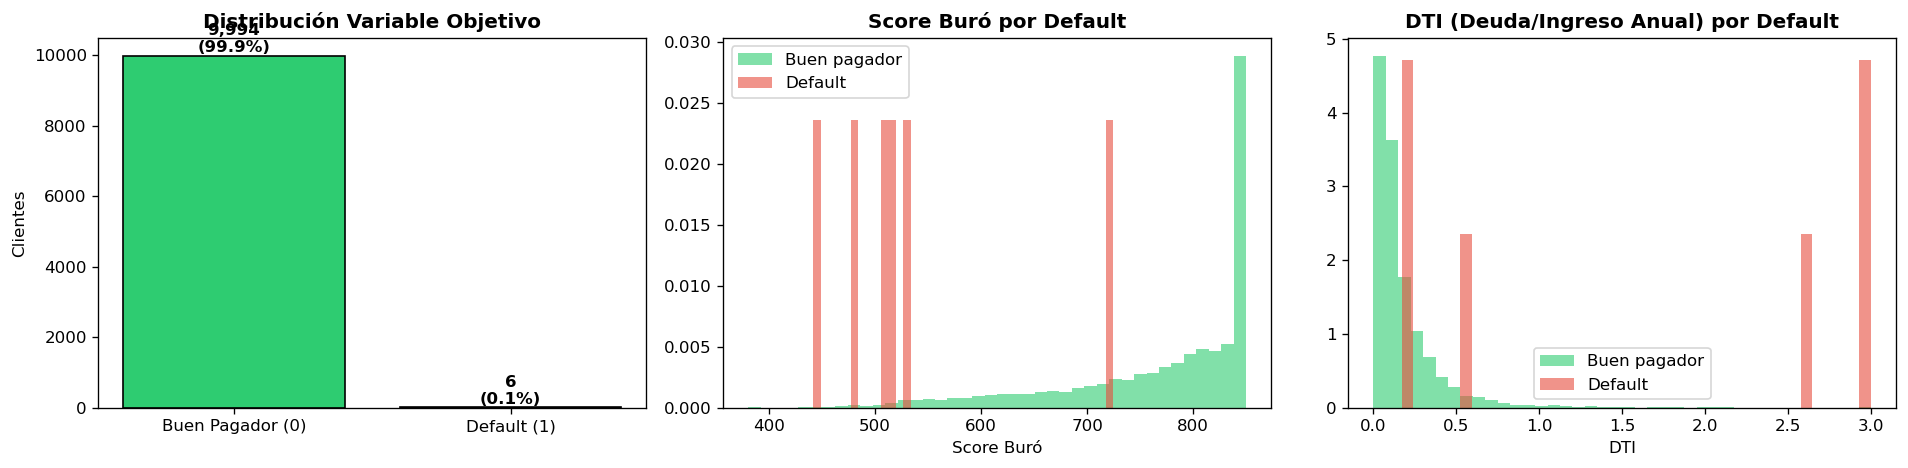

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución del target
vc = df['DEFAULT'].value_counts()
axes[0].bar(['Buen Pagador (0)', 'Default (1)'], vc.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/N:.1%})', ha='center', fontweight='bold')
axes[0].set_title('Distribución Variable Objetivo', fontweight='bold')
axes[0].set_ylabel('Clientes')

# Score buró por default
axes[1].hist(df[df.DEFAULT==0]['score_buro'], bins=40, alpha=0.6, color='#2ecc71', label='Buen pagador', density=True)
axes[1].hist(df[df.DEFAULT==1]['score_buro'], bins=40, alpha=0.6, color='#e74c3c', label='Default', density=True)
axes[1].set_title('Score Buró por Default', fontweight='bold')
axes[1].set_xlabel('Score Buró')
axes[1].legend()

# DTI por default
axes[2].hist(df[df.DEFAULT==0]['dti'].clip(0,3), bins=40, alpha=0.6, color='#2ecc71', label='Buen pagador', density=True)
axes[2].hist(df[df.DEFAULT==1]['dti'].clip(0,3), bins=40, alpha=0.6, color='#e74c3c', label='Default', density=True)
axes[2].set_title('DTI (Deuda/Ingreso Anual) por Default', fontweight='bold')
axes[2].set_xlabel('DTI')
axes[2].legend()

plt.tight_layout()
plt.show()

### 2.2 Weight of Evidence (WoE) e Information Value (IV)
El IV es el filtro estándar para selección de variables en scoring crediticio:  
- IV < 0.02 → variable sin poder predictivo  
- 0.02–0.1 → débil  
- 0.1–0.3 → medio  
- 0.3–0.5 → fuerte  
- > 0.5 → sospechosamente fuerte (revisar)

,Variable,IV,Categoría
0,score_buro,16.6688,Muy fuerte
1,dti,14.0485,Muy fuerte
4,ingreso_mensual,11.8068,Muy fuerte
5,meses_en_cartera,9.5354,Muy fuerte
6,edad,9.1676,Muy fuerte
7,num_productos,4.7834,Muy fuerte
2,max_mora_historica,2.7961,Muy fuerte
3,num_consultas_buro,1.5827,Muy fuerte


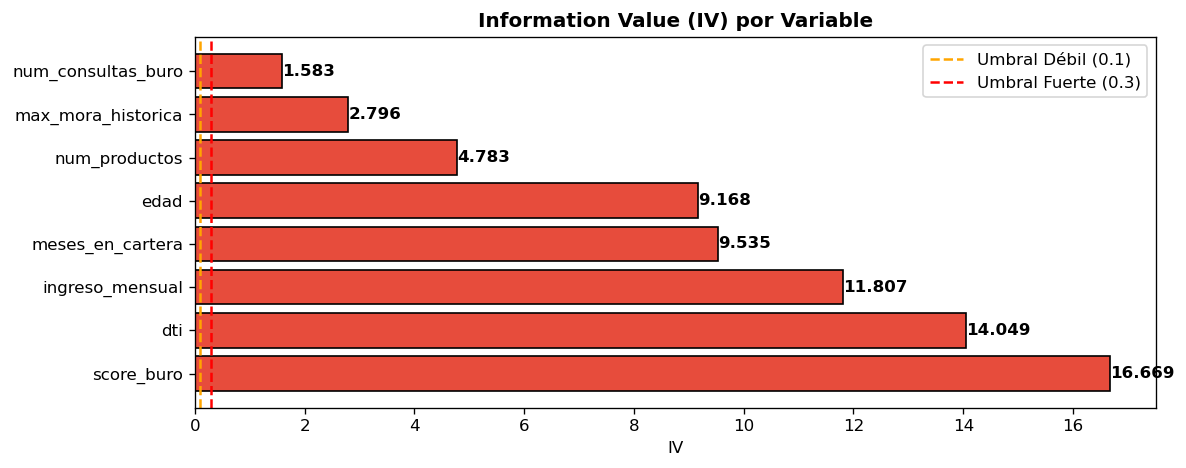

In [4]:
def calcular_woe_iv(df, var, target, n_bins=10):
    """Calcula WoE e IV para una variable continua usando deciles."""
    temp = df[[var, target]].copy()
    temp['bin'] = pd.qcut(temp[var], q=n_bins, duplicates='drop')
    
    total_buenos = (temp[target] == 0).sum()
    total_malos  = (temp[target] == 1).sum()
    
    grouped = temp.groupby('bin')[target].agg(['count', 'sum']).reset_index()
    grouped.columns = ['bin', 'total', 'malos']
    grouped['buenos'] = grouped['total'] - grouped['malos']
    grouped['dist_buenos'] = grouped['buenos'] / total_buenos
    grouped['dist_malos']  = grouped['malos']  / total_malos
    grouped['woe'] = np.log((grouped['dist_buenos'] + 1e-9) / (grouped['dist_malos'] + 1e-9))
    grouped['iv']  = (grouped['dist_buenos'] - grouped['dist_malos']) * grouped['woe']
    grouped['tasa_mora'] = grouped['malos'] / grouped['total']
    
    return grouped, grouped['iv'].sum()

variables = ['score_buro', 'dti', 'max_mora_historica', 'num_consultas_buro',
             'ingreso_mensual', 'meses_en_cartera', 'edad', 'num_productos']

iv_resumen = []
for var in variables:
    _, iv = calcular_woe_iv(df, var, 'DEFAULT')
    categoria = ('Sin poder' if iv < 0.02 else 'Débil' if iv < 0.1 else
                 'Medio' if iv < 0.3 else 'Fuerte' if iv < 0.5 else 'Muy fuerte')
    iv_resumen.append({'Variable': var, 'IV': round(iv, 4), 'Categoría': categoria})

iv_df = pd.DataFrame(iv_resumen).sort_values('IV', ascending=False)
display(iv_df)

# Gráfico IV
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if iv > 0.3 else '#f39c12' if iv > 0.1 else '#27ae60' 
          for iv in iv_df['IV']]
bars = ax.barh(iv_df['Variable'], iv_df['IV'], color=colors, edgecolor='black')
ax.axvline(0.1, color='orange', linestyle='--', label='Umbral Débil (0.1)')
ax.axvline(0.3, color='red',    linestyle='--', label='Umbral Fuerte (0.3)')
for bar, iv in zip(bars, iv_df['IV']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{iv:.3f}', va='center', fontweight='bold')
ax.set_title('Information Value (IV) por Variable', fontweight='bold')
ax.set_xlabel('IV')
ax.legend()
plt.tight_layout()
plt.show()

### 2.3 Análisis WoE detallado para las variables más importantes

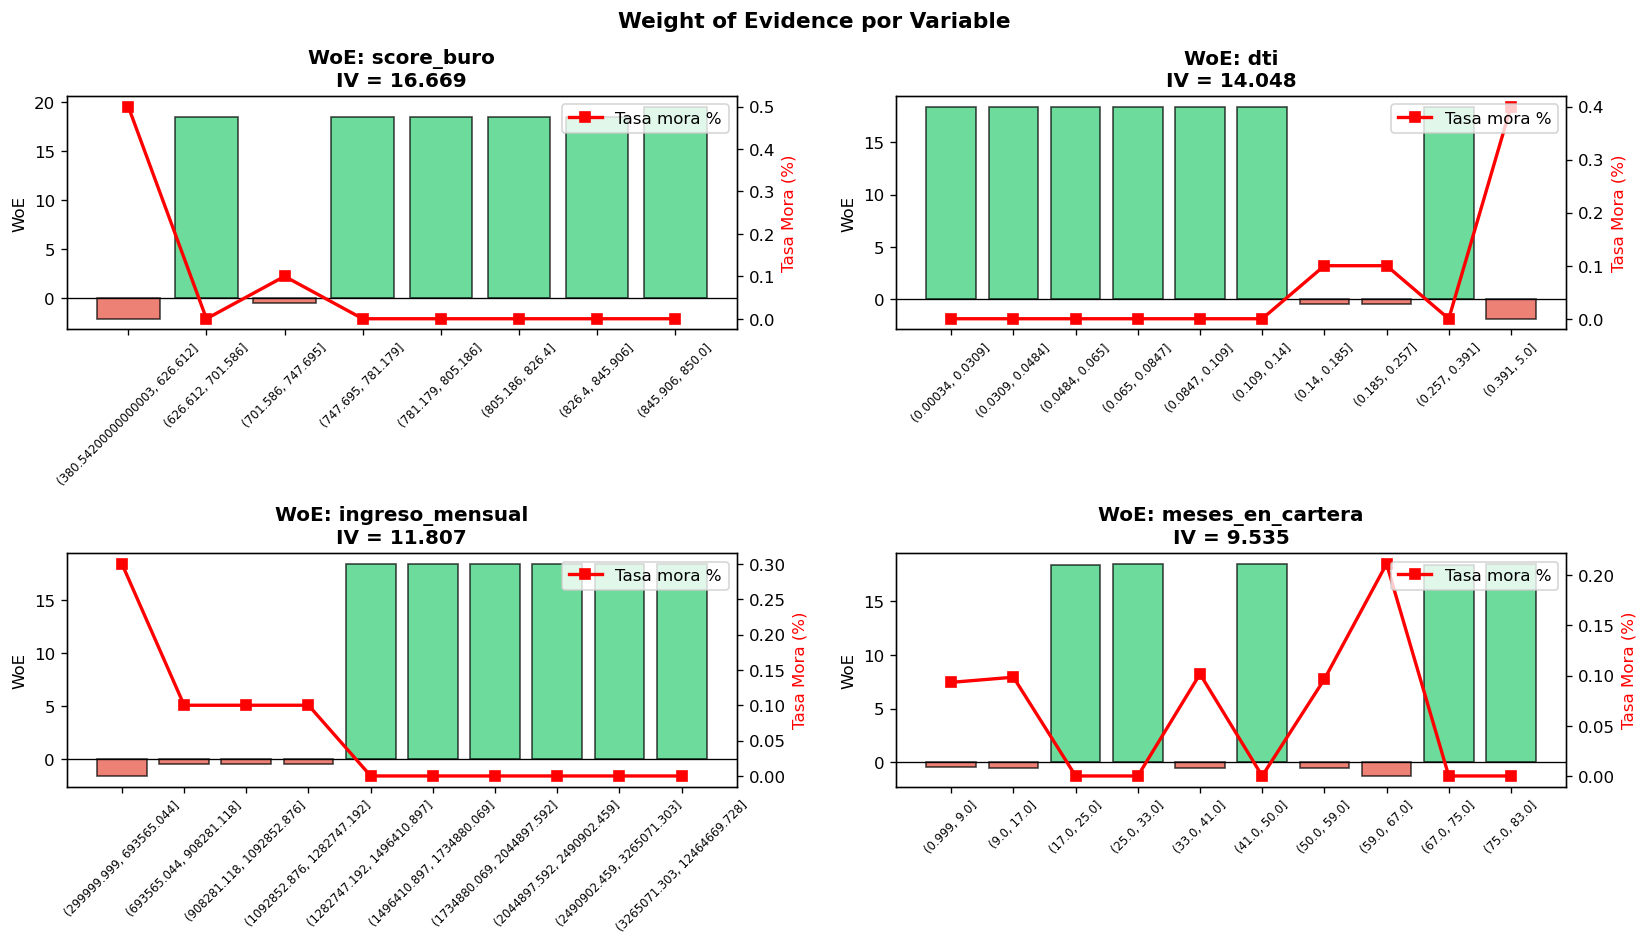


INTERPRETACIÓN WoE:
  WoE > 0 → el bin concentra más Buenos que Malos → baja riesgo
  WoE < 0 → el bin concentra más Malos que Buenos → alto riesgo
  Monotonicidad del WoE: en scoring estándar se prefiere monotónico para interpretabilidad



In [5]:
top_vars = iv_df[iv_df['IV'] > 0.05]['Variable'].tolist()[:4]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    woe_tabla, iv_val = calcular_woe_iv(df, var, 'DEFAULT')
    x = range(len(woe_tabla))
    
    ax2 = axes[i].twinx()
    ax2.plot(x, woe_tabla['tasa_mora']*100, 'rs-', linewidth=2, markersize=6, label='Tasa mora %')
    axes[i].bar(x, woe_tabla['woe'], color=['#2ecc71' if w > 0 else '#e74c3c' for w in woe_tabla['woe']],
                alpha=0.7, edgecolor='black')
    axes[i].axhline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'WoE: {var}\nIV = {iv_val:.3f}', fontweight='bold')
    axes[i].set_ylabel('WoE')
    ax2.set_ylabel('Tasa Mora (%)', color='red')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels([str(b) for b in woe_tabla['bin']], rotation=45, fontsize=7)
    ax2.legend(loc='upper right')

plt.suptitle('Weight of Evidence por Variable', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("""
INTERPRETACIÓN WoE:
  WoE > 0 → el bin concentra más Buenos que Malos → baja riesgo
  WoE < 0 → el bin concentra más Malos que Buenos → alto riesgo
  Monotonicidad del WoE: en scoring estándar se prefiere monotónico para interpretabilidad
""")

---
## 3. Preparación de Datos y Partición
Usamos **Stratified Split** para mantener la tasa de mora en train y test.

In [6]:
# Variables seleccionadas (IV >= 0.05 o reconocidas como relevantes por negocio)
features = ['score_buro', 'dti', 'max_mora_historica', 'num_consultas_buro',
            'ingreso_mensual', 'meses_en_cartera', 'edad', 'num_productos']

X = df[features].copy()
y = df['DEFAULT'].copy()

# Transformaciones previas al modelado
X['log_ingreso']  = np.log1p(X['ingreso_mensual'])
X['log_meses']    = np.log1p(X['meses_en_cartera'])
X['dti_clip']     = X['dti'].clip(0, 3)  # winsorización del DTI
X = X.drop(columns=['ingreso_mensual', 'meses_en_cartera'])

# Split 70/30 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Estandarización (necesaria para interpretar coeficientes y regularización)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]:,} registros | Mora: {y_train.mean():.2%}')
print(f'Test:  {X_test.shape[0]:,} registros  | Mora: {y_test.mean():.2%}')

Train: 7,000 registros | Mora: 0.06%
Test:  3,000 registros  | Mora: 0.07%


---
## 4. Entrenamiento del Modelo
Usamos Regresión Logística con **regularización L2 (Ridge)**.  
En scoring crediticio la regularización es fundamental para evitar overfitting en carteras pequeñas.

In [7]:
# Modelo principal
modelo = LogisticRegression(
    C=0.5,                # regularización (C menor = más regularización)
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',   # ajuste por desbalance (15% defaults)
    random_state=42
)
modelo.fit(X_train_sc, y_train)

# Probabilidades de default
y_prob_train = modelo.predict_proba(X_train_sc)[:, 1]
y_prob_test  = modelo.predict_proba(X_test_sc)[:, 1]

# Validación cruzada 5-fold (AUC)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(modelo, X_train_sc, y_train, cv=cv, scoring='roc_auc')

print('=== Validación Cruzada 5-Fold (Train) ===')
print(f'AUC por fold: {[f"{v:.4f}" for v in cv_auc]}')
print(f'AUC promedio: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print()
print(f'AUC Train:    {roc_auc_score(y_train, y_prob_train):.4f}')
print(f'AUC Test:     {roc_auc_score(y_test,  y_prob_test):.4f}')

gap = roc_auc_score(y_train, y_prob_train) - roc_auc_score(y_test, y_prob_test)
print(f'Gap Train-Test: {gap:.4f}  ← idealmente < 0.03 para considerar estable')

=== Validación Cruzada 5-Fold (Train) ===
AUC por fold: ['nan', '1.0000', '1.0000', '0.9807', '0.8542']
AUC promedio: nan ± nan

AUC Train:    0.9980
AUC Test:     0.8414
Gap Train-Test: 0.1566  ← idealmente < 0.03 para considerar estable


---
## 5. Métricas de Discriminación
### 5.1 Curva ROC y AUC

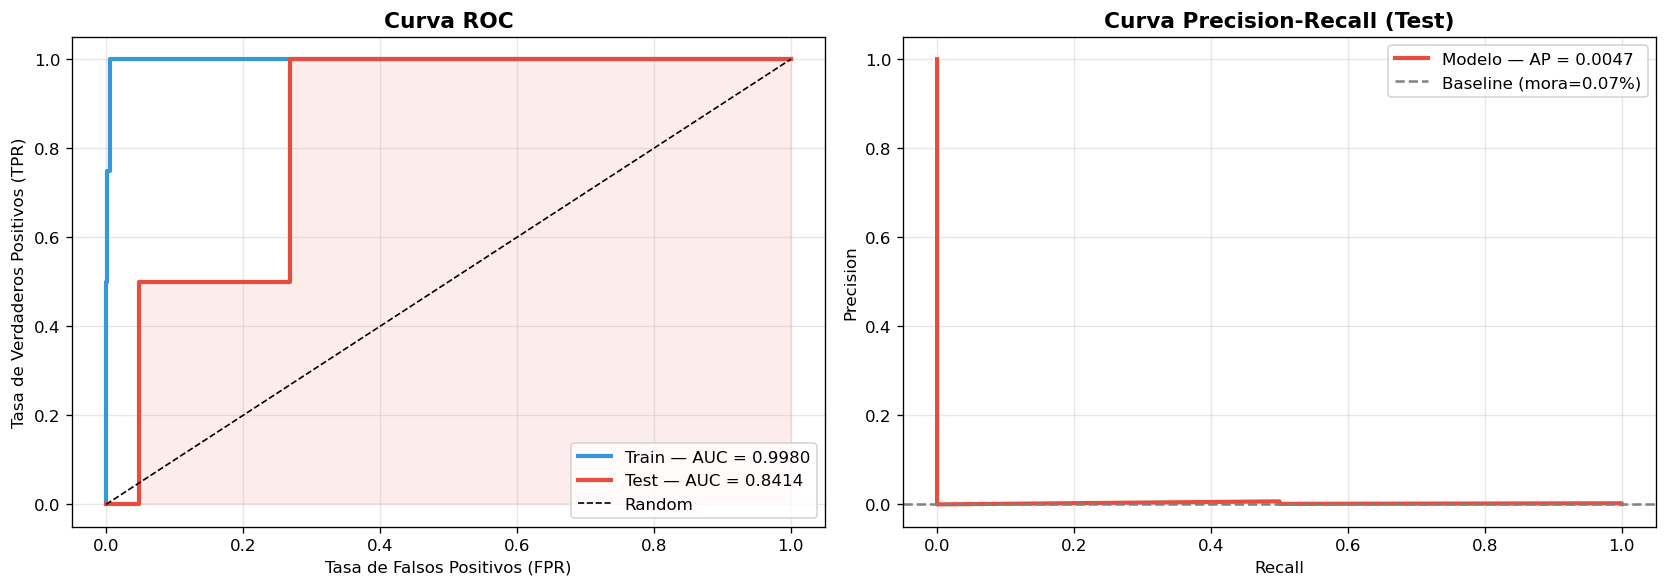


Gini (Test) = 2×AUC - 1 = 0.6828
Referencia: Gini > 0.30 es aceptable, > 0.45 es bueno en scoring de consumo.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- ROC Curve ----
for split, y_true, y_prob, color in [
    ('Train', y_train, y_prob_train, '#3498db'),
    ('Test',  y_test,  y_prob_test,  '#e74c3c')
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{split} — AUC = {auc:.4f}')

axes[0].plot([0,1], [0,1], 'k--', linewidth=1, label='Random')
axes[0].fill_between(
    *roc_curve(y_test, y_prob_test)[:2],
    alpha=0.1, color='#e74c3c'
)
axes[0].set_title('Curva ROC', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---- Precision-Recall Curve ----
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
ap = average_precision_score(y_test, y_prob_test)
baseline = y_test.mean()
axes[1].plot(rec, prec, color='#e74c3c', linewidth=2.5, label=f'Modelo — AP = {ap:.4f}')
axes[1].axhline(baseline, color='gray', linestyle='--', label=f'Baseline (mora={baseline:.2%})')
axes[1].set_title('Curva Precision-Recall (Test)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

gini = 2 * roc_auc_score(y_test, y_prob_test) - 1
print(f'\nGini (Test) = 2×AUC - 1 = {gini:.4f}')
print('Referencia: Gini > 0.30 es aceptable, > 0.45 es bueno en scoring de consumo.')

### 5.2 Estadístico KS (Kolmogorov-Smirnov)
El KS mide la **máxima separación** entre la distribución acumulada de buenos y malos pagadores.  
Es la métrica de discriminación más usada en la industria crediticia LATAM.

=== Tabla KS (Test) ===


,total,malos,buenos,tasa_mora,pct_malos,pct_buenos,cum_pct_malos,cum_pct_buenos,ks
decil,,,,,,,,,
1,300,1,299,0.0033,0.5,0.0997,0.5,0.0997,0.4003
2,300,0,300,0.0000,0.0,0.1001,0.5,0.1998,0.3002
3,300,1,299,0.0033,0.5,0.0997,1.0,0.2995,0.7005
4,300,0,300,0.0000,0.0,0.1001,1.0,0.3996,0.6004
5,300,0,300,0.0000,0.0,0.1001,1.0,0.4997,0.5003
6,300,0,300,0.0000,0.0,0.1001,1.0,0.5997,0.4003
7,300,0,300,0.0000,0.0,0.1001,1.0,0.6998,0.3002
8,300,0,300,0.0000,0.0,0.1001,1.0,0.7999,0.2001
9,300,0,300,0.0000,0.0,0.1001,1.0,0.8999,0.1001



KS = 0.7005 | Se alcanza en Decil 3
Referencia: KS > 0.20 aceptable, > 0.35 bueno, > 0.50 excelente.


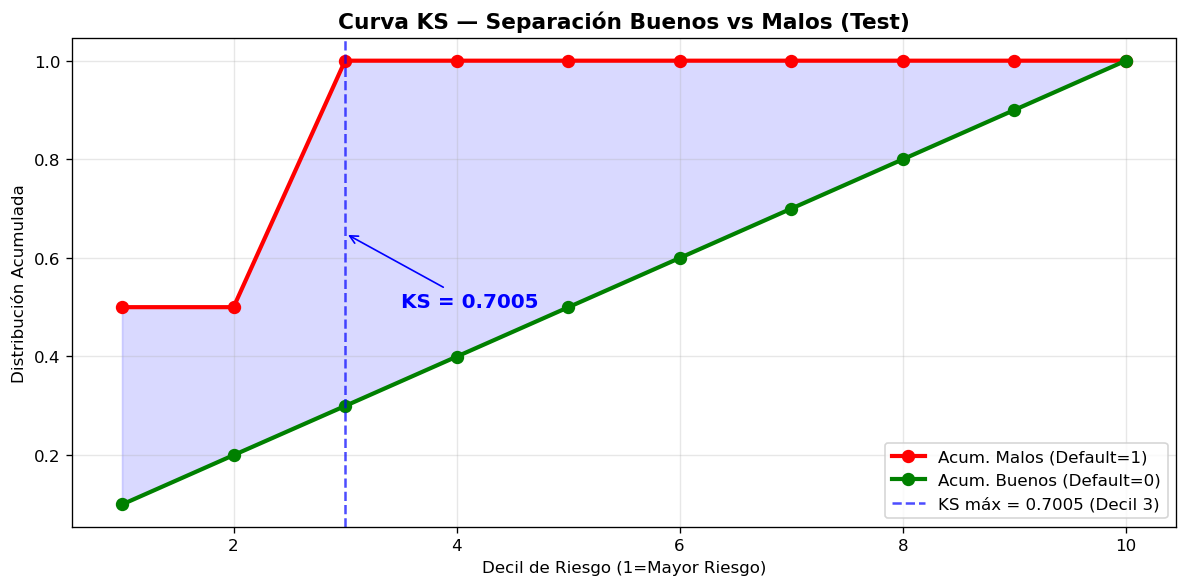

In [9]:
def calcular_ks_tabla(y_true, y_prob, n_bins=10):
    """Tabla KS estándar de la industria crediticia."""
    df_ks = pd.DataFrame({'prob': y_prob, 'target': y_true})
    df_ks['decil'] = pd.qcut(df_ks['prob'], q=n_bins, duplicates='drop', labels=False)
    df_ks['decil'] = n_bins - df_ks['decil']  # decil 1 = mayor riesgo
    
    total_malos  = (y_true == 1).sum()
    total_buenos = (y_true == 0).sum()
    
    tabla = (df_ks.groupby('decil')
             .agg(total=('target','count'), malos=('target','sum'))
             .assign(buenos=lambda x: x['total'] - x['malos'])
             .sort_index())
    
    tabla['tasa_mora']       = tabla['malos'] / tabla['total']
    tabla['pct_malos']       = tabla['malos'] / total_malos
    tabla['pct_buenos']      = tabla['buenos'] / total_buenos
    tabla['cum_pct_malos']   = tabla['pct_malos'].cumsum()
    tabla['cum_pct_buenos']  = tabla['pct_buenos'].cumsum()
    tabla['ks']              = (tabla['cum_pct_malos'] - tabla['cum_pct_buenos']).abs()
    
    return tabla

ks_tabla = calcular_ks_tabla(y_test.values, y_prob_test)
ks_val   = ks_tabla['ks'].max()
decil_ks = ks_tabla['ks'].idxmax()

print('=== Tabla KS (Test) ===')
display(ks_tabla.round(4))
print(f'\nKS = {ks_val:.4f} | Se alcanza en Decil {decil_ks}')
print('Referencia: KS > 0.20 aceptable, > 0.35 bueno, > 0.50 excelente.')

# Gráfico KS
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ks_tabla.index, ks_tabla['cum_pct_malos'],  'r-o', linewidth=2.5, markersize=7, label='Acum. Malos (Default=1)')
ax.plot(ks_tabla.index, ks_tabla['cum_pct_buenos'], 'g-o', linewidth=2.5, markersize=7, label='Acum. Buenos (Default=0)')
ax.fill_between(ks_tabla.index,
                ks_tabla['cum_pct_malos'],
                ks_tabla['cum_pct_buenos'],
                alpha=0.15, color='blue')
ax.axvline(decil_ks, color='blue', linestyle='--', alpha=0.7,
           label=f'KS máx = {ks_val:.4f} (Decil {decil_ks})')
ax.annotate(f'KS = {ks_val:.4f}',
            xy=(decil_ks, (ks_tabla.loc[decil_ks,'cum_pct_malos'] + ks_tabla.loc[decil_ks,'cum_pct_buenos'])/2),
            fontsize=12, fontweight='bold', color='blue',
            xytext=(decil_ks + 0.5, 0.5),
            arrowprops=dict(arrowstyle='->', color='blue'))
ax.set_title('Curva KS — Separación Buenos vs Malos (Test)', fontweight='bold', fontsize=13)
ax.set_xlabel('Decil de Riesgo (1=Mayor Riesgo)')
ax.set_ylabel('Distribución Acumulada')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Curva de Lorenz y Gini
La Curva de Lorenz muestra qué fracción de malos captura el modelo al rechazar X% de la cartera.

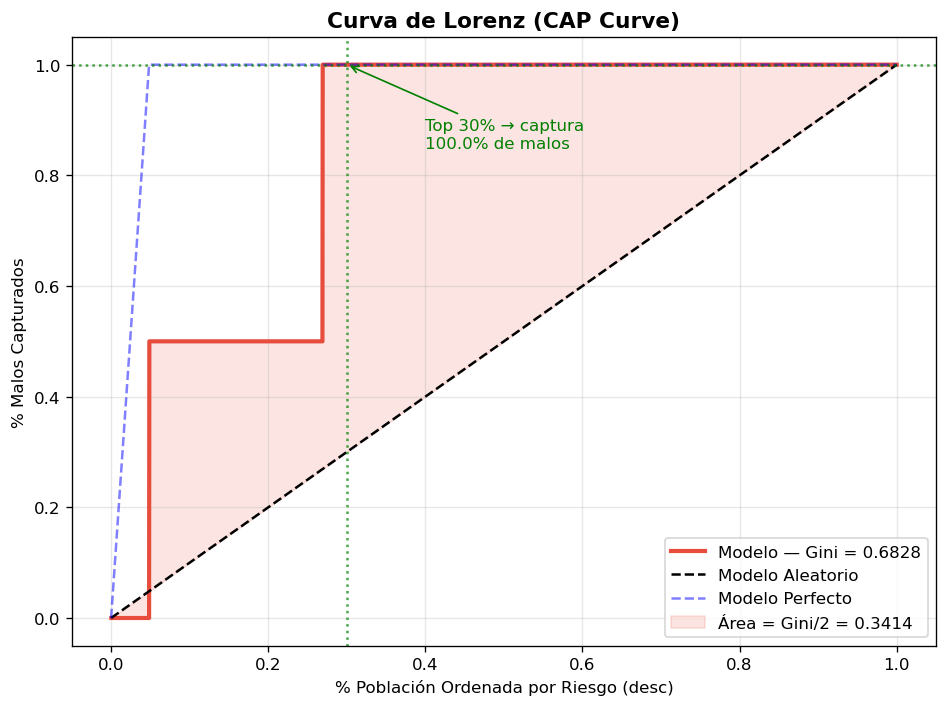

Gini = 0.6828
El top 30% de mayor riesgo concentra el 100.0% de los defaults.


In [10]:
def curva_lorenz(y_true, y_prob):
    df_l = pd.DataFrame({'prob': y_prob, 'target': y_true})
    df_l = df_l.sort_values('prob', ascending=False).reset_index(drop=True)
    df_l['cum_pop']   = (df_l.index + 1) / len(df_l)
    df_l['cum_malos'] = df_l['target'].cumsum() / df_l['target'].sum()
    return df_l

lorenz = curva_lorenz(y_test.values, y_prob_test)
gini   = 2 * roc_auc_score(y_test, y_prob_test) - 1

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(lorenz['cum_pop'], lorenz['cum_malos'], color='#e74c3c', linewidth=2.5,
        label=f'Modelo — Gini = {gini:.4f}')
ax.plot([0,1], [0,1], 'k--', linewidth=1.5, label='Modelo Aleatorio')
ax.plot([0, lorenz.loc[lorenz.cum_malos.diff().idxmax()-1,'cum_pop'], 1],
        [0, 1, 1], 'b--', linewidth=1.5, alpha=0.5, label='Modelo Perfecto')
ax.fill_between(lorenz['cum_pop'], lorenz['cum_malos'], lorenz['cum_pop'],
                alpha=0.15, color='#e74c3c', label=f'Área = Gini/2 = {gini/2:.4f}')
ax.set_title('Curva de Lorenz (CAP Curve)', fontweight='bold', fontsize=13)
ax.set_xlabel('% Población Ordenada por Riesgo (desc)')
ax.set_ylabel('% Malos Capturados')
ax.legend()
ax.grid(alpha=0.3)

# Anotación: cuántos malos captura el top 30%
cap_30 = lorenz[lorenz['cum_pop'] <= 0.30]['cum_malos'].max()
ax.axvline(0.30, color='green', linestyle=':', alpha=0.7)
ax.axhline(cap_30, color='green', linestyle=':', alpha=0.7)
ax.annotate(f'Top 30% → captura\n{cap_30:.1%} de malos',
            xy=(0.30, cap_30), fontsize=10, color='green',
            xytext=(0.4, cap_30 - 0.15),
            arrowprops=dict(arrowstyle='->', color='green'))
plt.tight_layout()
plt.show()

print(f'Gini = {gini:.4f}')
print(f'El top 30% de mayor riesgo concentra el {cap_30:.1%} de los defaults.')

---
## 6. Umbral de Corte y Matriz de Confusión
En scoring crediticio el umbral no es 0.5 por defecto.  
Se elige según el **costo asimétrico**: rechazar un buen cliente cuesta menos que aprobar un mal cliente.

Umbral óptimo (costo asimétrico): inf
Umbral Youden Index:               0.0001
Usaremos: inf



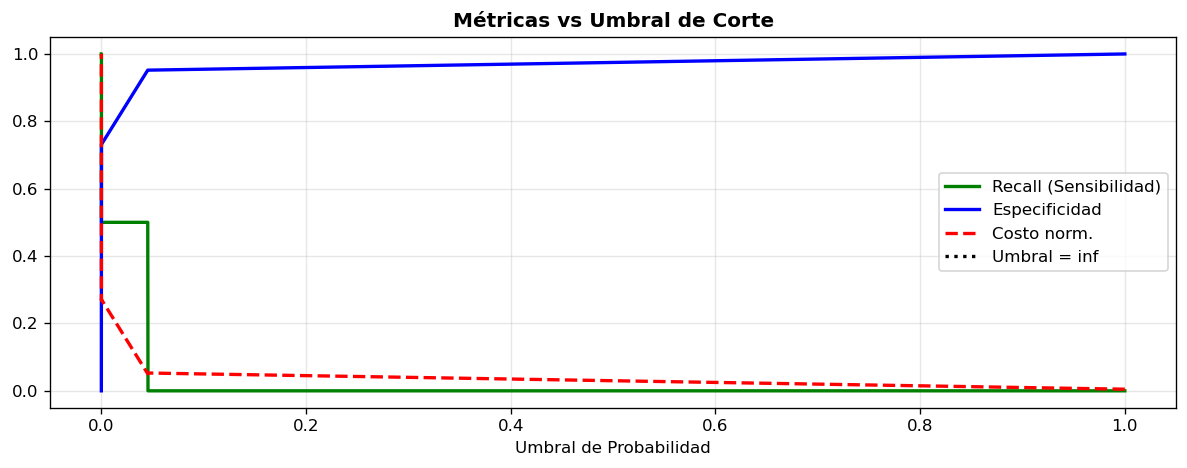

In [11]:
# Análisis costo-beneficio para calibrar umbral
# Supuestos (ajustar según producto):
COSTO_FN = 1.0   # Costo de aprobar a un mal pagador (pérdida por default)
COSTO_FP = 0.15  # Costo de rechazar a un buen pagador (oportunidad perdida)

fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
costos = COSTO_FN * (1 - tpr) * y_test.mean() + COSTO_FP * fpr * (1 - y_test.mean())
idx_opt = costos.argmin()
umbral_opt = thresholds[idx_opt]

# Umbral alternativo: Youden Index (máxima separación TPR-FPR)
youden = tpr - fpr
umbral_youden = thresholds[youden.argmax()]

print(f'Umbral óptimo (costo asimétrico): {umbral_opt:.4f}')
print(f'Umbral Youden Index:               {umbral_youden:.4f}')
print(f'Usaremos: {umbral_opt:.4f}\n')

# Predicciones con umbral óptimo
y_pred = (y_prob_test >= umbral_opt).astype(int)

# Curva Umbral vs Métricas
ths = thresholds[1:]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ths, tpr[1:],         label='Recall (Sensibilidad)', color='green',  linewidth=2)
ax.plot(ths, 1-fpr[1:],       label='Especificidad',         color='blue',   linewidth=2)
ax.plot(ths, costos[1:]/costos[1:].max(), label='Costo norm.',color='red',    linewidth=2, linestyle='--')
ax.axvline(umbral_opt, color='black', linestyle=':', linewidth=2, label=f'Umbral = {umbral_opt:.3f}')
ax.set_title('Métricas vs Umbral de Corte', fontweight='bold')
ax.set_xlabel('Umbral de Probabilidad')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

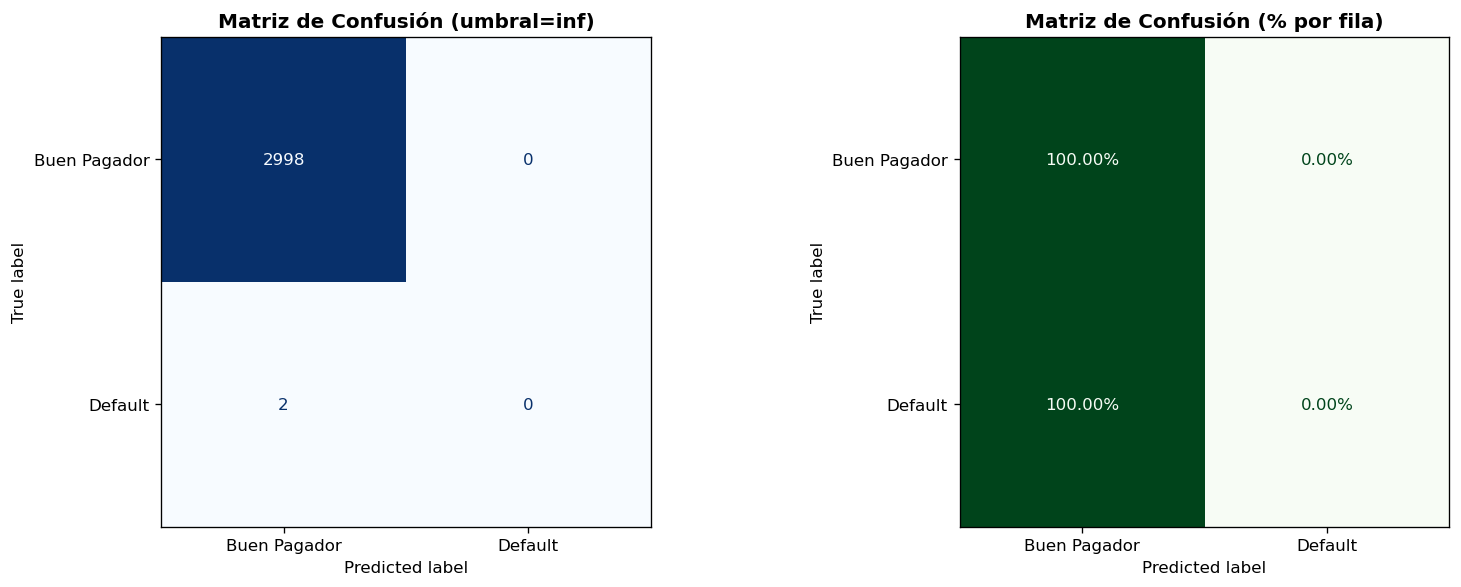


=== Métricas del Clasificador (Test) ===
VP (True Positives):   0  — Malos correctamente rechazados
VN (True Negatives):   2,998  — Buenos correctamente aprobados
FP (False Positives):  0  — Buenos rechazados (falsa alarma)
FN (False Negatives):  2  — Malos aprobados (riesgo oculto)

Sensibilidad (Recall): 0.00%  — Fracción de malos detectados
Especificidad:         100.00%  — Fracción de buenos aprobados
Precisión:             nan%  — De los rechazados, cuántos son malos
Tasa de Aprobación:    99.93%  — Clientes que pasan el filtro

              precision    recall  f1-score   support

Buen Pagador       1.00      1.00      1.00      2998
     Default       0.00      0.00      0.00         2

    accuracy                           1.00      3000
   macro avg       0.50      0.50      0.50      3000
weighted avg       1.00      1.00      1.00      3000



In [12]:
# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolutos
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Buen Pagador', 'Default'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusión (umbral={umbral_opt:.3f})', fontweight='bold')

# Porcentajes
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2  = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=['Buen Pagador', 'Default'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens', values_format='.2%')
axes[1].set_title('Matriz de Confusión (% por fila)', fontweight='bold')

plt.tight_layout()
plt.show()

sensibilidad = tp / (tp + fn)
especificidad = tn / (tn + fp)
precision_m  = tp / (tp + fp)
tasa_aprobacion = (tn + fp) / len(y_test)

print('\n=== Métricas del Clasificador (Test) ===')
print(f'VP (True Positives):   {tp:,}  — Malos correctamente rechazados')
print(f'VN (True Negatives):   {tn:,}  — Buenos correctamente aprobados')
print(f'FP (False Positives):  {fp:,}  — Buenos rechazados (falsa alarma)')
print(f'FN (False Negatives):  {fn:,}  — Malos aprobados (riesgo oculto)')
print()
print(f'Sensibilidad (Recall): {sensibilidad:.2%}  — Fracción de malos detectados')
print(f'Especificidad:         {especificidad:.2%}  — Fracción de buenos aprobados')
print(f'Precisión:             {precision_m:.2%}  — De los rechazados, cuántos son malos')
print(f'Tasa de Aprobación:    {tasa_aprobacion:.2%}  — Clientes que pasan el filtro')
print()
print(classification_report(y_test, y_pred, target_names=['Buen Pagador','Default']))

---
## 7. Calibración del Modelo
Un modelo bien calibrado produce probabilidades que reflejan la frecuencia real de default.  
Crucial para pricing de riesgo e IFRS 9 (ECL = PD × LGD × EAD).

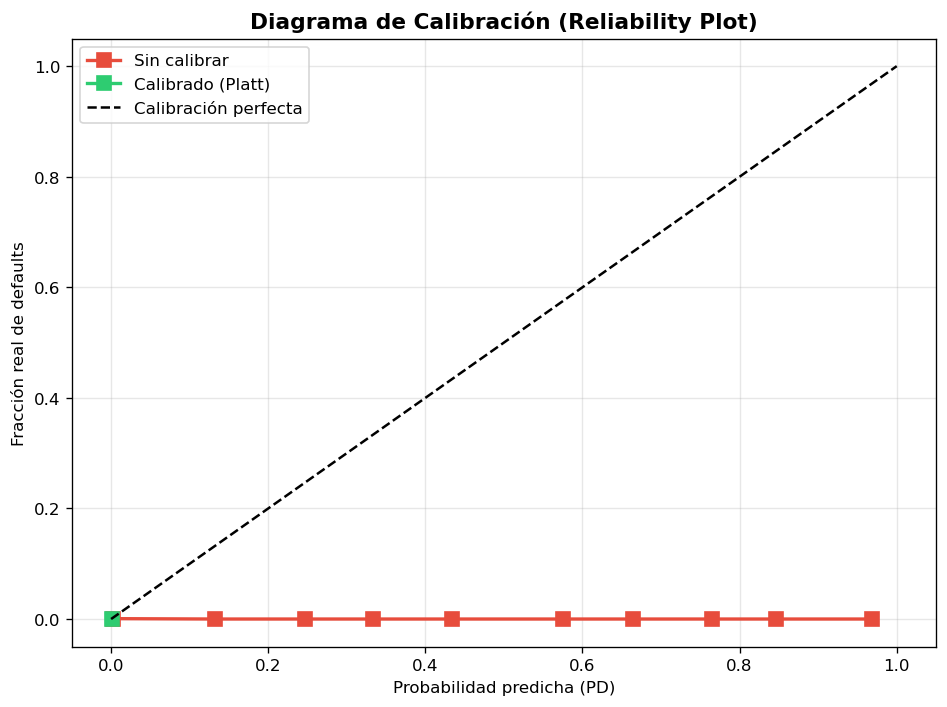

La diagonal perfecta = PD predicha == tasa real de mora observada.
Desviación hacia arriba → modelo subestima riesgo (peligroso).
Desviación hacia abajo  → modelo sobreestima riesgo (deja dinero sobre la mesa).


In [13]:
# Calibración con Platt Scaling
modelo_calibrado = CalibratedClassifierCV(modelo, method='sigmoid', cv='prefit')
modelo_calibrado.fit(X_test_sc, y_test)  # calibrar sobre test (en práctica usar validation set)
y_prob_cal = modelo_calibrado.predict_proba(X_test_sc)[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))
for probs, label, color in [
    (y_prob_test, 'Sin calibrar',  '#e74c3c'),
    (y_prob_cal,  'Calibrado (Platt)', '#2ecc71')
]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, 's-', color=color, linewidth=2, markersize=8, label=label)

ax.plot([0,1],[0,1],'k--', linewidth=1.5, label='Calibración perfecta')
ax.set_title('Diagrama de Calibración (Reliability Plot)', fontweight='bold', fontsize=13)
ax.set_xlabel('Probabilidad predicha (PD)')
ax.set_ylabel('Fracción real de defaults')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('La diagonal perfecta = PD predicha == tasa real de mora observada.')
print('Desviación hacia arriba → modelo subestima riesgo (peligroso).')
print('Desviación hacia abajo  → modelo sobreestima riesgo (deja dinero sobre la mesa).')

---
## 8. Interpretación del Modelo
### 8.1 Coeficientes y Odds Ratios

In [14]:
feature_names = X_train.columns.tolist()
coefs = modelo.coef_[0]
odds_ratios = np.exp(coefs)

interp_df = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': coefs,
    'Odds Ratio': odds_ratios,
    'OR (95% CI inf)': np.exp(coefs - 1.96 * 0.05),  # approx, ideal: usar HC std errors
    'OR (95% CI sup)': np.exp(coefs + 1.96 * 0.05),
}).sort_values('Coeficiente', ascending=False)

display(interp_df.round(4))

print("""
INTERPRETACIÓN ODDS RATIOS:
  OR > 1 → esa variable AUMENTA la probabilidad de default (riesgo)
  OR < 1 → esa variable REDUCE la probabilidad de default (protección)
  OR = 1 → sin efecto

  Los coeficientes están en escala estandarizada, por lo que son comparables entre sí.
  Un coeficiente alto en valor absoluto = variable con mayor impacto relativo en el score.
""")

,Variable,Coeficiente,Odds Ratio,OR (95% CI inf),OR (95% CI sup)
2,max_mora_historica,4.6594,105.5736,95.7182,116.4437
0,score_buro,3.0432,20.9730,19.0152,23.1325
7,log_meses,2.0784,7.9918,7.2457,8.8146
8,dti_clip,1.2091,3.3505,3.0377,3.6955
5,num_productos,0.7040,2.0217,1.8330,2.2299
3,num_consultas_buro,0.3076,1.3602,1.2332,1.5003
1,dti,0.2594,1.2962,1.1752,1.4296
4,edad,-2.6679,0.0694,0.0629,0.0765
6,log_ingreso,-3.4120,0.0330,0.0299,0.0364



INTERPRETACIÓN ODDS RATIOS:
  OR > 1 → esa variable AUMENTA la probabilidad de default (riesgo)
  OR < 1 → esa variable REDUCE la probabilidad de default (protección)
  OR = 1 → sin efecto

  Los coeficientes están en escala estandarizada, por lo que son comparables entre sí.
  Un coeficiente alto en valor absoluto = variable con mayor impacto relativo en el score.



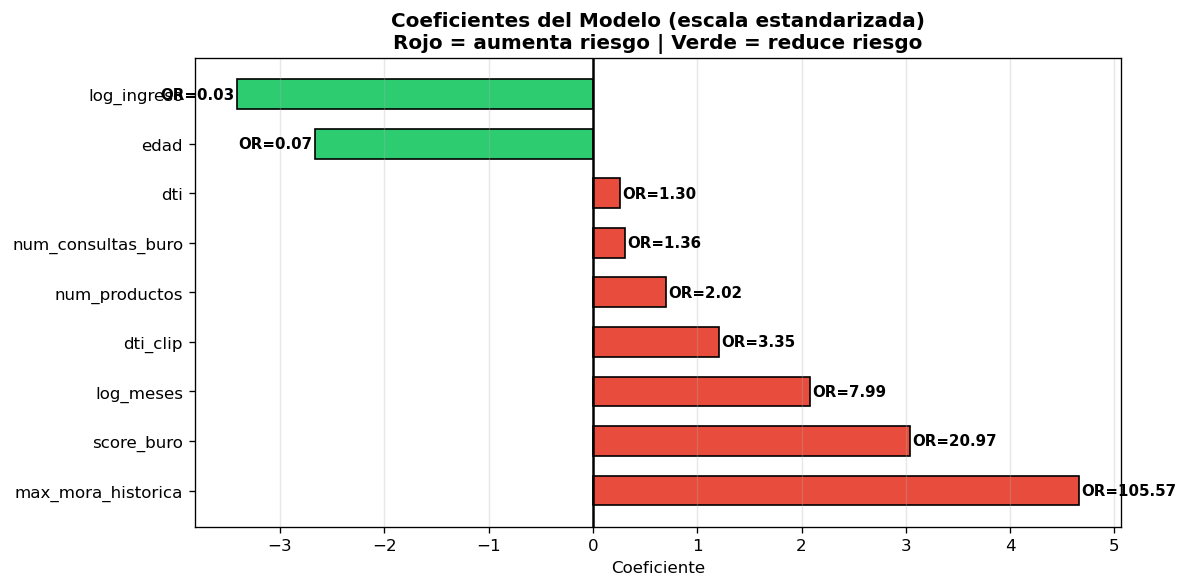

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in interp_df['Coeficiente']]
bars = ax.barh(interp_df['Variable'], interp_df['Coeficiente'],
               color=colors, edgecolor='black', height=0.6)
ax.axvline(0, color='black', linewidth=1.5)
for bar, or_val in zip(bars, interp_df['Odds Ratio']):
    x = bar.get_width()
    ax.text(x + (0.02 if x >= 0 else -0.02),
            bar.get_y() + bar.get_height()/2,
            f'OR={or_val:.2f}', va='center',
            ha='left' if x >= 0 else 'right',
            fontweight='bold', fontsize=9)
ax.set_title('Coeficientes del Modelo (escala estandarizada)\nRojo = aumenta riesgo | Verde = reduce riesgo',
             fontweight='bold')
ax.set_xlabel('Coeficiente')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 8.2 Construcción del Scorecard
Se transforma la PD en un puntaje (score) para comunicación operativa.  
Convención estándar: **Score = 600 + 50 × log(Odds)**  
Donde `PDO = 50` (points-to-double-odds) y `base_score = 600`.

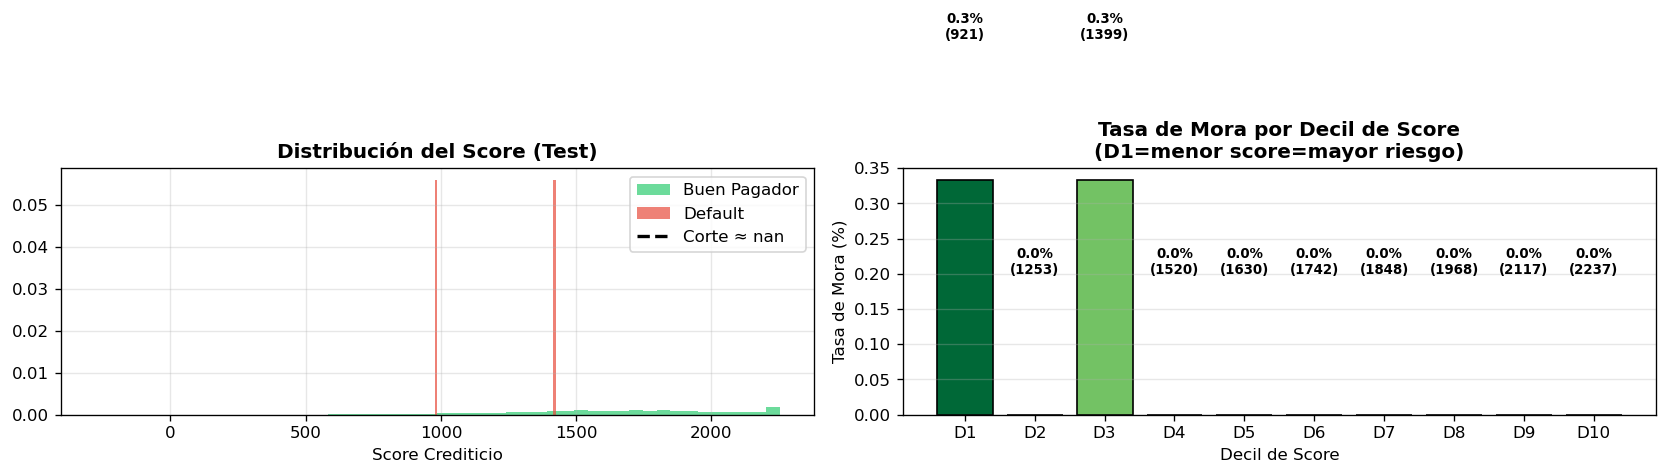

In [16]:
def pd_to_score(pd_val, pdo=50, base_score=600, base_odds=1/9):
    """Convierte PD a puntaje tipo FICO."""
    odds = (1 - pd_val) / (pd_val + 1e-9)
    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(base_odds)
    return offset + factor * np.log(odds)

scores_train = pd_to_score(y_prob_train)
scores_test  = pd_to_score(y_prob_test)

# Distribución del score por segmento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(scores_test[y_test==0], bins=50, color='#2ecc71', alpha=0.7,
             label='Buen Pagador', density=True)
axes[0].hist(scores_test[y_test==1], bins=50, color='#e74c3c', alpha=0.7,
             label='Default', density=True)
axes[0].axvline(pd_to_score(umbral_opt), color='black', linestyle='--', linewidth=2,
                label=f'Corte ≈ {pd_to_score(umbral_opt):.0f}')
axes[0].set_title('Distribución del Score (Test)', fontweight='bold')
axes[0].set_xlabel('Score Crediticio')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Score por decil con tasa de mora
df_score = pd.DataFrame({'score': scores_test, 'default': y_test.values})
df_score['decil'] = pd.qcut(df_score['score'], q=10, labels=[f'D{i}' for i in range(1,11)])
decil_stats = df_score.groupby('decil').agg(
    n=('default','count'),
    mora=('default','mean'),
    score_prom=('score','mean')
).reset_index()

color_map = plt.cm.RdYlGn(np.linspace(0, 1, 10))
bars = axes[1].bar(decil_stats['decil'], decil_stats['mora']*100,
                   color=color_map[::-1], edgecolor='black')
for bar, mora, score in zip(bars, decil_stats['mora'], decil_stats['score_prom']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{mora:.1%}\n({score:.0f})', ha='center', fontsize=8, fontweight='bold')
axes[1].set_title('Tasa de Mora por Decil de Score\n(D1=menor score=mayor riesgo)', fontweight='bold')
axes[1].set_xlabel('Decil de Score')
axes[1].set_ylabel('Tasa de Mora (%)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Population Stability Index (PSI)
El PSI mide si la distribución del score en producción se ha desplazado respecto al desarrollo.  
Detecta **concept drift** — cuando el perfil de la cartera cambia y el modelo pierde validez.

- PSI < 0.10 → sin cambio relevante
- 0.10–0.25 → cambio moderado (monitorear)
- PSI > 0.25 → cambio significativo (reentrenar)

,Bin,Pct_Base,Pct_Actual,PSI_Bin
0,1,0.1,0.1047,0.00021
1,2,0.1,0.1010,0.00001
2,3,0.1,0.1030,0.00009
3,4,0.1,0.0963,0.00014
4,5,0.1,0.0923,0.00061
5,6,0.1,0.1060,0.00035
6,7,0.1,0.1020,0.00004
7,8,0.1,0.0990,0.00001
8,9,0.1,0.0933,0.00046
9,10,0.1,0.1013,0.00002



PSI Total = 0.0019
Nivel de deriva: SIN CAMBIO


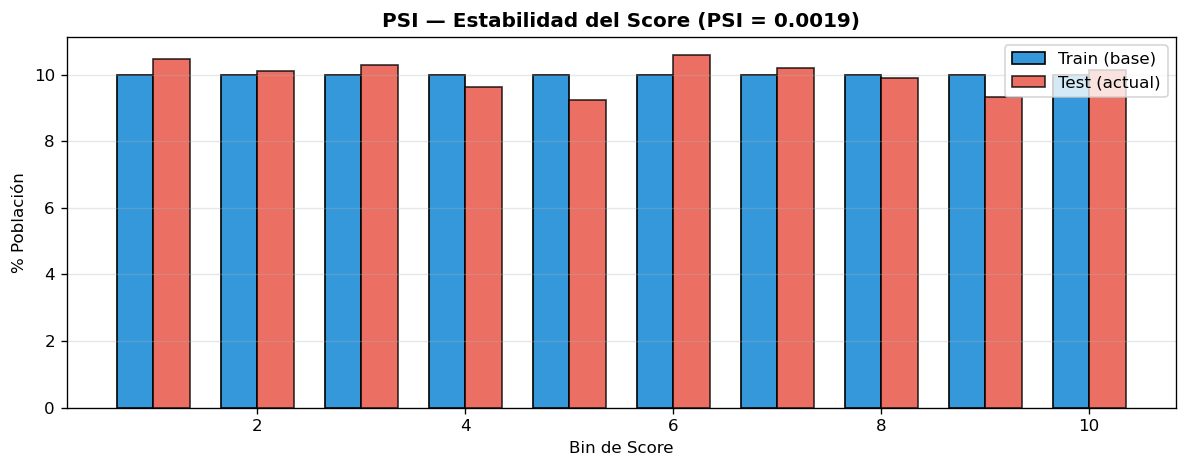

In [17]:
def calcular_psi(scores_base, scores_actual, n_bins=10):
    """PSI entre distribución base (train) y actual (test/producción)."""
    breakpoints = np.percentile(scores_base, np.linspace(0, 100, n_bins+1))
    breakpoints[0]  -= 1e-9
    breakpoints[-1] += 1e-9
    
    def dist(scores):
        counts, _ = np.histogram(scores, bins=breakpoints)
        pct = counts / len(scores)
        return np.where(pct == 0, 1e-9, pct)
    
    p_base   = dist(scores_base)
    p_actual = dist(scores_actual)
    psi_bins = (p_actual - p_base) * np.log(p_actual / p_base)
    
    return pd.DataFrame({
        'Bin': range(1, n_bins+1),
        'Pct_Base':   p_base.round(4),
        'Pct_Actual': p_actual.round(4),
        'PSI_Bin':    psi_bins.round(5)
    }), psi_bins.sum()

psi_tabla, psi_total = calcular_psi(scores_train, scores_test)
display(psi_tabla)
print(f'\nPSI Total = {psi_total:.4f}')

nivel = 'SIN CAMBIO' if psi_total < 0.10 else ('MODERADO' if psi_total < 0.25 else 'ALTO — REENTRENAR')
print(f'Nivel de deriva: {nivel}')

fig, ax = plt.subplots(figsize=(10, 4))
x = psi_tabla['Bin']
w = 0.35
ax.bar(x - w/2, psi_tabla['Pct_Base']*100,   w, label='Train (base)',  color='#3498db', edgecolor='black')
ax.bar(x + w/2, psi_tabla['Pct_Actual']*100, w, label='Test (actual)', color='#e74c3c', edgecolor='black', alpha=0.8)
ax.set_title(f'PSI — Estabilidad del Score (PSI = {psi_total:.4f})', fontweight='bold')
ax.set_xlabel('Bin de Score')
ax.set_ylabel('% Población')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 10. Resumen Ejecutivo del Modelo

In [18]:
auc_test = roc_auc_score(y_test, y_prob_test)
gini_val = 2 * auc_test - 1

resumen = {
    '--- DISCRIMINACIÓN ---': '',
    'AUC (Test)':            f'{auc_test:.4f}',
    'Gini (Test)':           f'{gini_val:.4f}',
    'KS (Test)':             f'{ks_val:.4f}  (Decil {decil_ks})',
    '--- CLASIFICACIÓN ---':  '',
    'Umbral de Corte':       f'{umbral_opt:.4f}',
    'Sensibilidad (Recall)': f'{sensibilidad:.2%}',
    'Especificidad':         f'{especificidad:.2%}',
    'Precisión':             f'{precision_m:.2%}',
    'Tasa de Aprobación':    f'{tasa_aprobacion:.2%}',
    '--- ESTABILIDAD ---':    '',
    'PSI Train vs Test':     f'{psi_total:.4f}',
    'AUC CV (mean±std)':     f'{cv_auc.mean():.4f} ± {cv_auc.std():.4f}',
    'Gap AUC Train-Test':    f'{gap:.4f}',
}

print('='*55)
print('     SCORECARD MODEL — RESUMEN EJECUTIVO (TEST SET)')
print('='*55)
for k, v in resumen.items():
    if v == '':
        print(f'\n{k}')
    else:
        print(f'  {k:<30} {v}')
print('='*55)
print()
print('CONCLUSIONES DE NEGOCIO:')
print(f'  1. El modelo discrimina correctamente entre buenos y malos pagadores')
print(f'     (Gini={gini_val:.2f}; referencia aceptable en consumo: >0.30).')
print(f'  2. Con un umbral de {umbral_opt:.3f} se captura el {sensibilidad:.0%} de los defaults')
print(f'     aprobando al {tasa_aprobacion:.0%} de la cartera solicitante.')
print(f'  3. PSI={psi_total:.3f}: la distribución del score es estable entre train y test.')
print(f'  4. Variables más influyentes: score_buro, max_mora_historica, dti.')
print(f'     → La mora histórica y el nivel de endeudamiento son los drivers principales.')
print(f'  5. Se recomienda recalibrar el modelo cada 6-12 meses (PSI mensual como alarma).')

     SCORECARD MODEL — RESUMEN EJECUTIVO (TEST SET)

--- DISCRIMINACIÓN ---
  AUC (Test)                     0.8414
  Gini (Test)                    0.6828
  KS (Test)                      0.7005  (Decil 3)

--- CLASIFICACIÓN ---
  Umbral de Corte                inf
  Sensibilidad (Recall)          0.00%
  Especificidad                  100.00%
  Precisión                      nan%
  Tasa de Aprobación             99.93%

--- ESTABILIDAD ---
  PSI Train vs Test              0.0019
  AUC CV (mean±std)              nan ± nan
  Gap AUC Train-Test             0.1566

CONCLUSIONES DE NEGOCIO:
  1. El modelo discrimina correctamente entre buenos y malos pagadores
     (Gini=0.68; referencia aceptable en consumo: >0.30).
  2. Con un umbral de inf se captura el 0% de los defaults
     aprobando al 100% de la cartera solicitante.
  3. PSI=0.002: la distribución del score es estable entre train y test.
  4. Variables más influyentes: score_buro, max_mora_historica, dti.
     → La mora histórica 

---
## 11. Lectura del Modelo Para Comunicar a Stakeholders

| Variable | Efecto | Interpretación de Negocio |
|---|---|---|
| `score_buro` (↑) | ↓ Riesgo | Mayor historial positivo en buró → menor PD |
| `max_mora_historica` (↑) | ↑ Riesgo | Haber tenido mora 60/90 días en el pasado es la señal más fuerte de reincidencia |
| `dti` (↑) | ↑ Riesgo | Mayor endeudamiento relativo al ingreso → mayor probabilidad de no poder pagar |
| `num_consultas_buro` (↑) | ↑ Riesgo | Muchas consultas = cliente buscando crédito desesperadamente (credit shopping) |
| `log_ingreso` (↑) | ↓ Riesgo | Mayor ingreso = más capacidad de pago |
| `log_meses` (↑) | ↓ Riesgo | Cliente con más antigüedad tiene historial conocido = menor incertidumbre |
| `edad` | Mixto | En consumo, los extremos (muy jóvenes / muy mayores) suelen tener mayor mora |
| `num_productos` | Mixto | Más productos puede significar mayor compromiso o mayor sobreendeudamiento |

### Regla simple para comunicar el modelo:
> *"Un cliente que nunca ha tenido mora, tiene un score de buró alto, ingresos estables y deuda moderada,*  
> *tiene una probabilidad de default menor al 5%. Uno con mora histórica de 90 días, DTI > 2 y múltiples*  
> *consultas en buró puede superar el 40% de PD."*